In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from keras.src.metrics.accuracy_metrics import accuracy

In [65]:
data = pd.read_csv('data.csv')

data.head()

y = data.iloc[:, 0]  # Bankrupt
X = data.iloc[:, 1:]  # All 95 features

print(f"Total companies: {len(data)}")
print(f"Bankruptcies: {y.sum()}")
print(f"Bankruptcy rate: {y.mean():.2%}")

Total companies: 6819
Bankruptcies: 220
Bankruptcy rate: 3.23%


Features shape: (6819, 95)
Top correlations with target:
Bankrupt?                               1.000000
 Debt ratio %                           0.250161
 Current Liability to Assets            0.194494
 Borrowing dependency                   0.176543
 Current Liability to Current Assets    0.171306
 Liability to Equity                    0.166812
 Current Liabilities/Equity             0.153828
 Current Liability to Equity            0.153828
 Liability-Assets Flag                  0.139212
 Total expense/Assets                   0.139049
Name: Bankrupt?, dtype: float64
Strongest negative correlations with target:
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Net profit before tax/Paid-in capital                     -0.207857
Retained Earnings to Total Assets                         -0.217779
Persistent EPS in the Last Four Seasons                   -0.219560
Net worth/Assets                                          -0.250161
ROA(C) before interest and depreciat

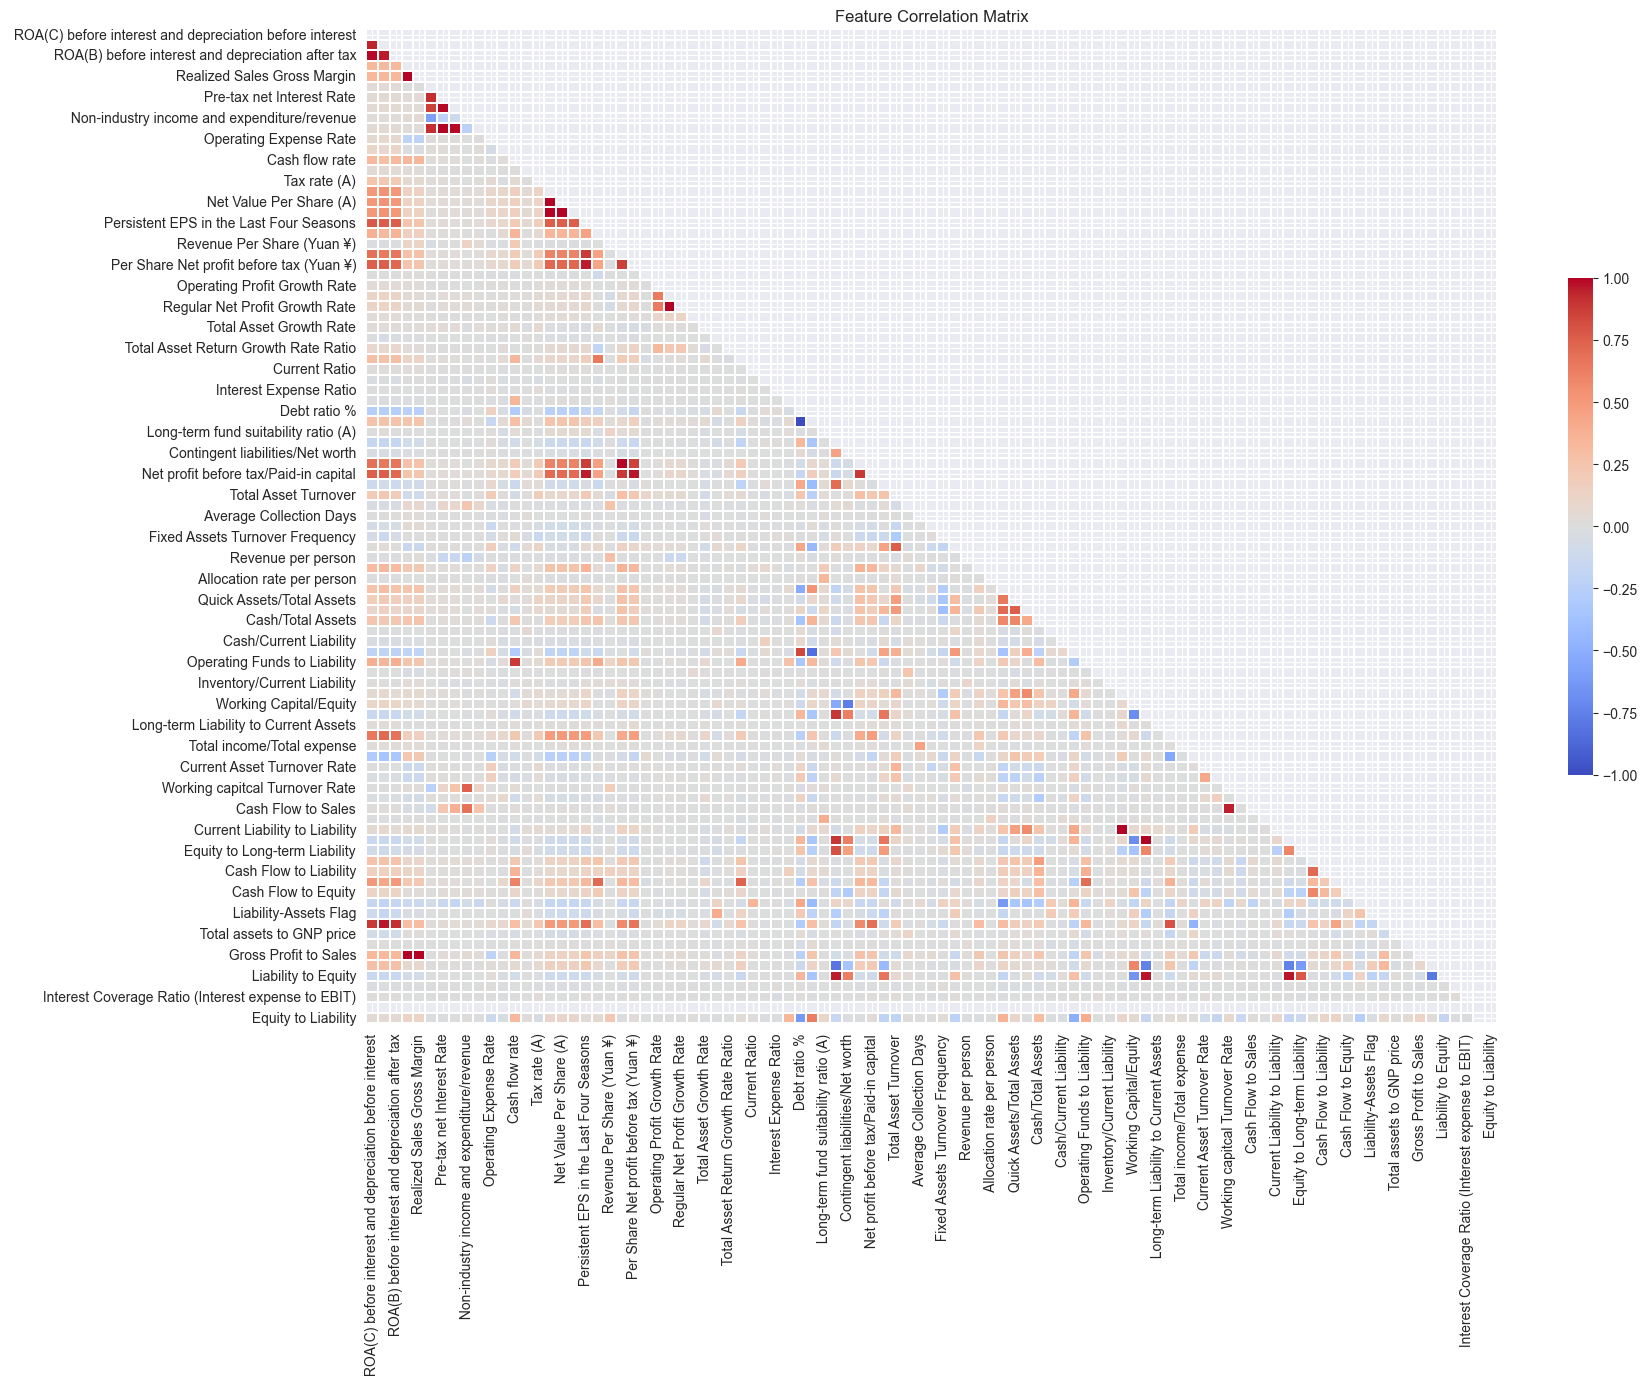

In [66]:
# compute correlations only between features (exclude target column)
target_col = data.columns[0]  # "Bankrupt?"
X_original = data.drop(columns=[target_col])

# feature correlation matrix
corr = X_original.corr()
print(f"Features shape: {X.shape}")

# correlations with the target (for reference)
corr_with_target = data.corr()[target_col].sort_values(ascending=False)
print("Top correlations with target:")
print(corr_with_target.head(10))
print("Strongest negative correlations with target:")
print(corr_with_target.tail(10))

# function returning strongly correlated pairs
def high_corr_pairs(corr_df, thresh=0.8):
    pairs = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack()
    return pairs[abs(pairs) > thresh].sort_values(ascending=False)

thresh = 0.9
strong_pairs = high_corr_pairs(corr, thresh)
print(f"\nFeature pairs with |corr| > {thresh} (count: {len(strong_pairs)}):")
print(strong_pairs)

# function proposing redundant features to drop (deterministic: drop the second feature in each pair)
def get_redundant_features(corr_df, thresh=0.9):
    to_drop = set()
    cols = corr_df.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr_df.iloc[i, j]) > thresh:
                to_drop.add(cols[j])
    return sorted(to_drop)

to_drop = get_redundant_features(corr, thresh)
print(f"\nProposed features to drop (|corr|>{thresh}): {len(to_drop)}")
print(to_drop)


# draw heatmap (mask upper triangle for readability)
plt.figure(figsize=(18,14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.01, cbar_kws={"shrink": .5})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("feature_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Original features: 95
Features after dropping: 76
Reduction: 19 features (20.0%)

Remaining feature pairs with |corr| > 0.9: 0
Success! No remaining pairs above threshold.

Pairs with |corr| > 0.7: 19


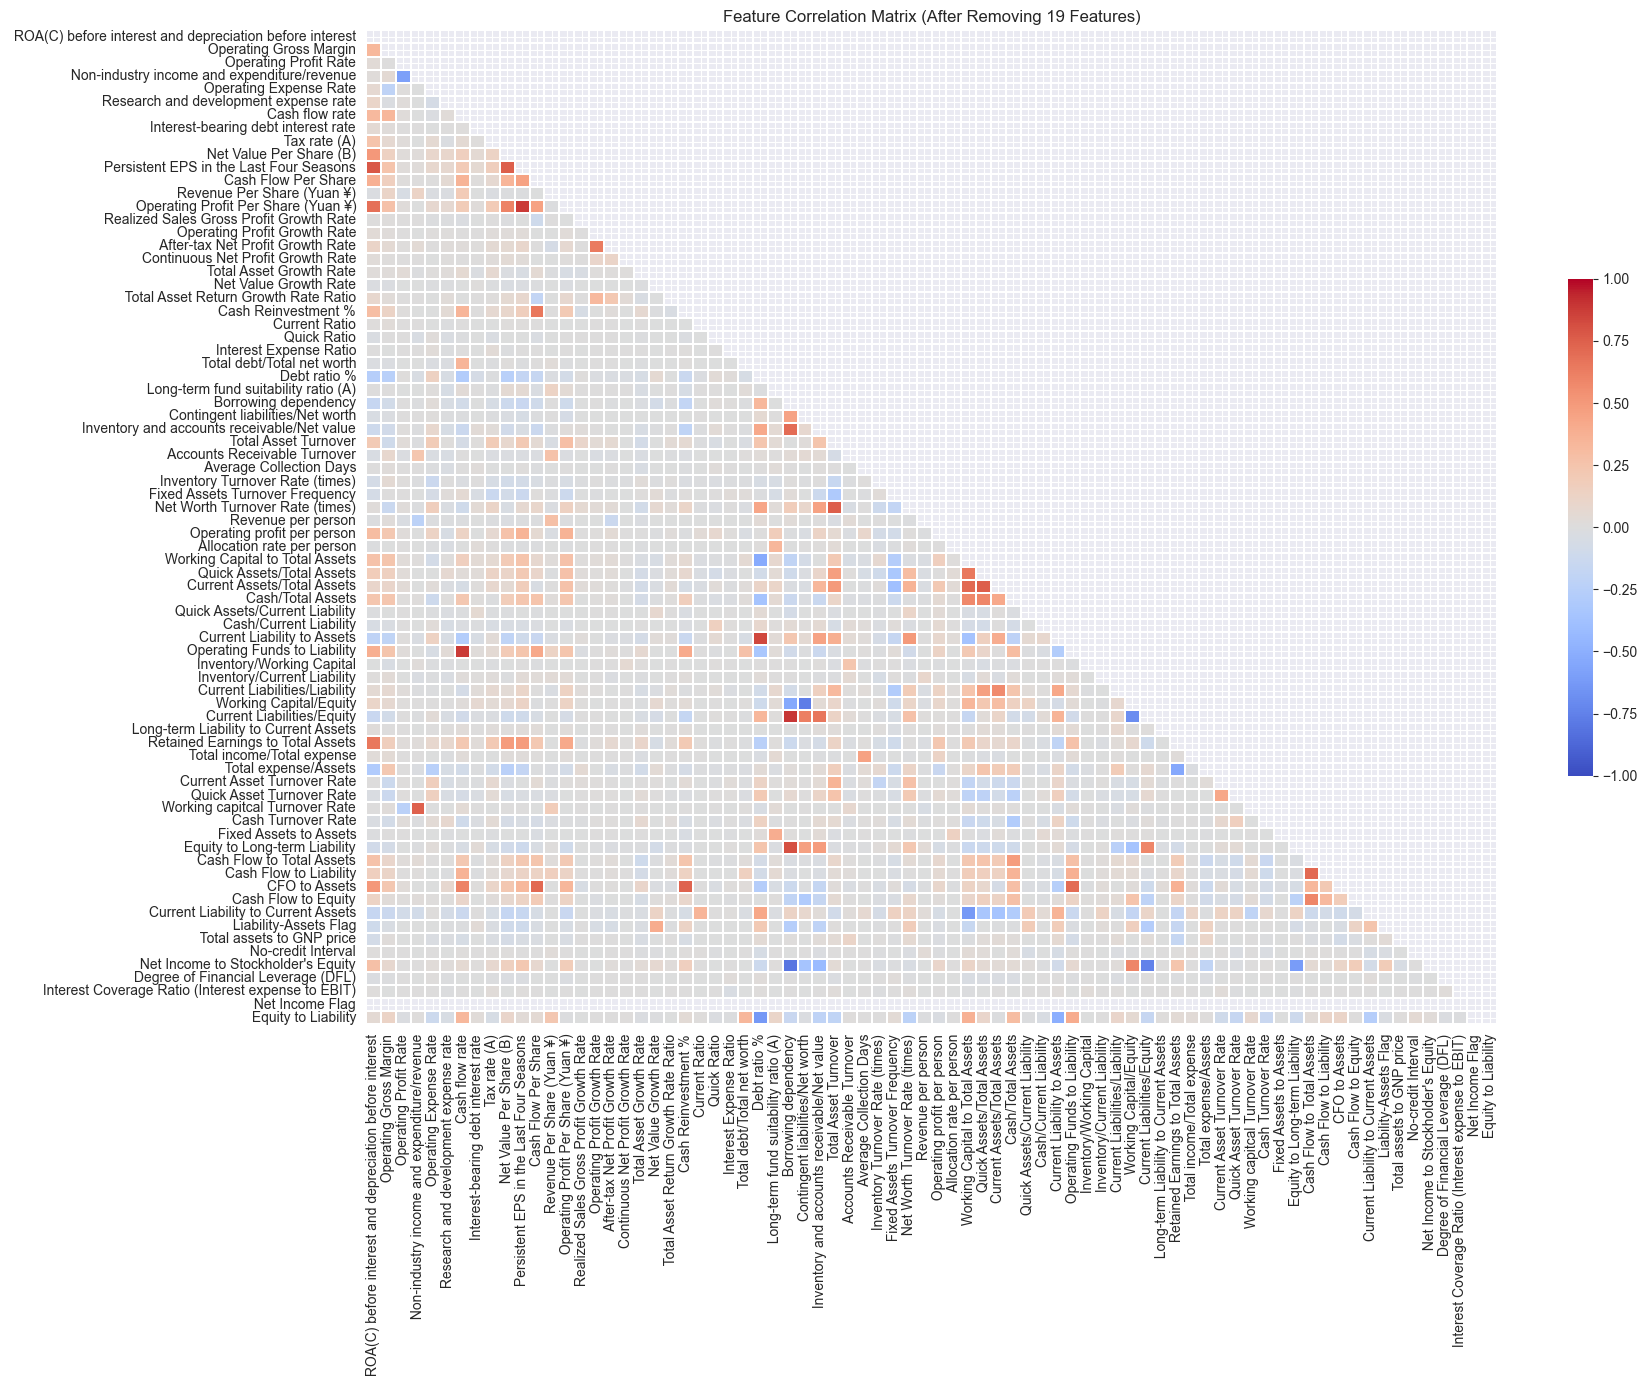

In [67]:
#We want to remove features that are highly correlated to make our model faster i guess
X_clean = X_original.drop(columns=to_drop)
X_clean.head()

print(f"Original features: {X.shape[1]}")
print(f"Features after dropping: {X_clean.shape[1]}")
print(f"Reduction: {X.shape[1] - X_clean.shape[1]} features ({(X.shape[1] - X_clean.shape[1])/X.shape[1]:.1%})")

corr_clean = X_clean.corr()

# check if there are still highly correlated pairs
remaining_pairs = high_corr_pairs(corr_clean, thresh=0.9)
print(f"\nRemaining feature pairs with |corr| > 0.9: {len(remaining_pairs)}")
if len(remaining_pairs) > 0:
    print("Warning: Still have highly correlated pairs!")
    print(remaining_pairs.head(10))
else:
    print("Success! No remaining pairs above threshold.")

lower_thresh_pairs = high_corr_pairs(corr_clean, thresh=0.7)
print(f"\nPairs with |corr| > 0.7: {len(lower_thresh_pairs)}")

plt.figure(figsize=(18,14))
mask = np.triu(np.ones_like(corr_clean, dtype=bool))
sns.heatmap(corr_clean, mask=mask, cmap="coolwarm", center=0, 
            vmin=-1, vmax=1, linewidths=0.01, cbar_kws={"shrink": .5})
plt.title(f"Feature Correlation Matrix (After Removing {len(to_drop)} Features)")
plt.tight_layout()
plt.savefig("feature_correlation_matrix_clean.png", dpi=300, bbox_inches="tight")
plt.show()

## Sci-kit classifier (Baseline)
After cleaning our data, we try the sci-kit classifier to provide a baseline for our research

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

strategies = ['most_frequent', 'stratified', 'uniform', 'constant']

test_scores = []

for strategy in strategies:
    if strategy == 'constant':
        dclf = DummyClassifier(strategy=strategy, random_state=0, constant=1)
    else:
        dclf = DummyClassifier(strategy=strategy, random_state=0)
    dclf.fit(X_train, y_train)
    score = dclf.score(X_test, y_test)
    test_scores.append(score)

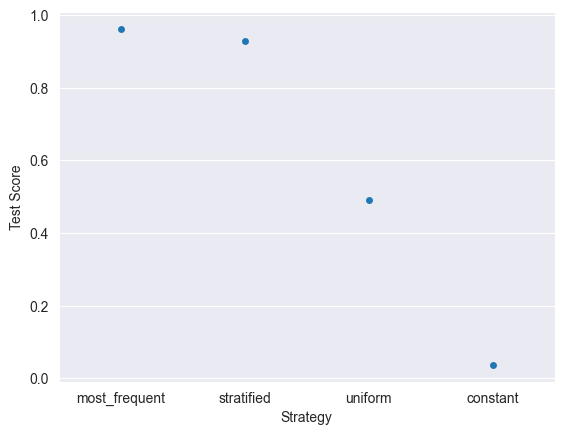

In [69]:
ax = sns.stripplot(x=strategies, y=test_scores)
ax.set(xlabel='Strategy', ylabel='Test Score')
plt.show()

## XGBClassifier

In [70]:
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=29.5,
    max_depth=10,
    learning_rate=0.01,
    n_estimators=200,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy:  0.9545454545454546

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1313
           1       0.42      0.59      0.49        51

    accuracy                           0.95      1364
   macro avg       0.70      0.78      0.73      1364
weighted avg       0.96      0.95      0.96      1364



The classes are seriously imbalanced. We need to implement balancing in order to predict class 1 efficiently


In [71]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, precision_recall_curve

y_prob = model.predict_proba(X_test)
y_prob_bankruptcy = y_prob[:, 1]

print(f"Probability predictions shape: {y_prob_bankruptcy.shape}")
print(f"Sample probabilities (first 10): {y_prob_bankruptcy[:10]}")
print(f"Min probability: {y_prob_bankruptcy.min():.3f}")
print(f"Max probability: {y_prob_bankruptcy.max():.3f}")

thresholds = np.arange(0.05, 1.0, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_bankruptcy > threshold).astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_threshold, average=None)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    results.append({
        "threshold": threshold,
        "precision": precision[1],
        "recall": recall[1],
        "f1": f1[1],
        "support": support,
        "fn": fn,
        "fp": fp,
        "tp": tp,
        "tn": tn,
        "total_predicted_bankrupt": tp + fp
    })

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("THRESHOLD TUNING RESULTS")
print("="*80)
print(results_df.to_string(index=False))

Probability predictions shape: (1364,)
Sample probabilities (first 10): [0.06623627 0.06846865 0.06518374 0.7954227  0.18418057 0.06593294
 0.07364961 0.06521076 0.06518374 0.06518374]
Min probability: 0.064
Max probability: 0.896

THRESHOLD TUNING RESULTS
 threshold  precision   recall       f1    support  fn   fp  tp   tn  total_predicted_bankrupt
      0.05   0.037390 1.000000 0.072085 [1313, 51]   0 1313  51    0                      1364
      0.10   0.144231 0.882353 0.247934 [1313, 51]   6  267  45 1046                       312
      0.15   0.207921 0.823529 0.332016 [1313, 51]   9  160  42 1153                       202
      0.20   0.257862 0.803922 0.390476 [1313, 51]  10  118  41 1195                       159
      0.25   0.295455 0.764706 0.426230 [1313, 51]  12   93  39 1220                       132
      0.30   0.354545 0.764706 0.484472 [1313, 51]  12   71  39 1242                       110
      0.35   0.380000 0.745098 0.503311 [1313, 51]  13   62  38 1251          

C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

Now we want to find a threshold that gives recall >= 0.8 with best precision

In [72]:
high_recall_results = results_df[results_df['recall'] >= 0.80]
if len(high_recall_results) > 0:
    best_precision_high_recall = high_recall_results.loc[high_recall_results['precision'].idxmax()]
    print("\n" + "="*80)
    print("BEST PRECISION WITH RECALL >= 0.80")
    print("="*80)
    print(f"Threshold: {best_precision_high_recall['threshold']:.2f}")
    print(f"Precision: {best_precision_high_recall['precision']:.3f}")
    print(f"Recall: {best_precision_high_recall['recall']:.3f}")
    print(f"F1-Score: {best_precision_high_recall['f1']:.3f}")
    print(f"Bankruptcies caught: {best_precision_high_recall['tp']:.0f} out of {support[1]}")
    print(f"False alarms: {best_precision_high_recall['fp']:.0f}")
else:
    print("\nNo threshold achieves recall >= 0.80")


BEST PRECISION WITH RECALL >= 0.80
Threshold: 0.20
Precision: 0.258
Recall: 0.804
F1-Score: 0.390
Bankruptcies caught: 41 out of 51
False alarms: 118


Lets try different oversampling methods and compare them

In [73]:
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN,
    BorderlineSMOTE,
    SVMSMOTE
)

from imblearn.combine import (
    SMOTETomek,
    SMOTEENN
)

oversampling_methods = {
    "No oversampling": None,

    "Random OverSampler": RandomOverSampler(
        sampling_strategy='auto',
        random_state=42
    ),

    "SMOTE (current)": SMOTE(
        sampling_strategy='auto',
        k_neighbors=5,
        random_state=42
    ),

    "SMOTE (current)": SMOTE(
        sampling_strategy='auto',
        k_neighbors=3,
        random_state=42
    ),

    "BorderlineSMOTE": BorderlineSMOTE(
        sampling_strategy='auto',
        random_state=42,
        k_neighbors=5,
        m_neighbors=10
    ),

    "ADASYN": ADASYN(
        sampling_strategy='auto',
        n_neighbors=5,
        random_state=42,
    ),

    "SVMSMOTE": SVMSMOTE(
        sampling_strategy='auto',
        k_neighbors=5,
        m_neighbors=10,
        random_state=42
    ),

    "SMOTETomek": SMOTETomek(
        sampling_strategy='auto',
        random_state=42
    ),

    "SMOTEENN": SMOTEENN(
        sampling_strategy='auto',
        random_state=42
    )
}

In [74]:
all_results = []

xgb_params = {
    'scale_pos_weight': 30,
    'max_depth': 5,
    'learning_rate': 0.01,
    'n_estimators': 200,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss'
}

print("="*80)
print("TESTING DIFFERENT OVERSAMPLING METHODS")
print("="*80)
print(f"\nOriginal training data distribution:")
print(f"Non-bankrupt: {(y_train == 0).sum()}")
print(f"Bankrupt: {(y_train == 1).sum()}")
print(f"Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")
print("\n")

TESTING DIFFERENT OVERSAMPLING METHODS

Original training data distribution:
Non-bankrupt: 5286
Bankrupt: 169
Ratio: 31.28:1




In [76]:
for method_name, sampler in oversampling_methods.items():
    print(f"\n{'='*80}")
    print(f"Testing {method_name}")
    print(f"\n{'='*80}")

    if sampler is None:
        X_res = X_train
        y_res = y_train
        print("No oversampling applied (baseline)")
    else:
        try:
            X_res, y_res = sampler.fit_resample(X_clean, y)
            X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

            print(f"After {method_name}:")
            print(f"  Non-bankrupt: {(y_res == 0).sum()}")
            print(f"  Bankrupt: {(y_res == 1).sum()}")
            print(f"  Ratio: {(y_res == 0).sum() / (y_res == 1).sum():.2f}:1")
            print(f"  Total samples: {len(y_res)} (was {len(y_train)})")

        except Exception as e:
            print(f"Error: {e}")
            print(f"Skipping {method_name}")
            continue

    model = XGBClassifier(**xgb_params)
    model.fit(X_res, y_res, verbose=False)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    result = {
        'Method': method_name,
        'Threshold': threshold,
        'Precision': precision[1],
        'Recall': recall[1],
        'F1': f1,
        'FN': fn,
        'FP': fp,
        'TP': tp,
        'TN': tn,
        'total_predicted_bankruptcies':  support[1],
        'Bankruptcies caught': tp,
        'Bankruptcies missed': fn,
        'False alarms': fp,
    }

    all_results.append(result)

    print(f"\n  Results on Test Set:")
    print(f"    Precision: {precision[1]:.3f}")
    print(f"    Recall: {recall[1]:.3f}")
    print(f"    F1-Score: {f1[1]:.3f}")
    print(f"    Bankruptcies caught: {tp}/{support[1]} ({tp/support[1]*100:.1f}%)")
    print(f"    False alarms: {fp}")



Testing No oversampling

No oversampling applied (baseline)

  Results on Test Set:
    Precision: 0.342
    Recall: 0.765
    F1-Score: 0.473
    Bankruptcies caught: 39/51 (76.5%)
    False alarms: 75

Testing Random OverSampler

After Random OverSampler:
  Non-bankrupt: 6599
  Bankrupt: 6599
  Ratio: 1.00:1
  Total samples: 13198 (was 10558)

  Results on Test Set:
    Precision: 0.789
    Recall: 1.000
    F1-Score: 0.882
    Bankruptcies caught: 1306/1306 (100.0%)
    False alarms: 350

Testing SMOTE (current)

After SMOTE (current):
  Non-bankrupt: 6599
  Bankrupt: 6599
  Ratio: 1.00:1
  Total samples: 13198 (was 10558)

  Results on Test Set:
    Precision: 0.826
    Recall: 1.000
    F1-Score: 0.905
    Bankruptcies caught: 1306/1306 (100.0%)
    False alarms: 275

Testing BorderlineSMOTE

After BorderlineSMOTE:
  Non-bankrupt: 6599
  Bankrupt: 6599
  Ratio: 1.00:1
  Total samples: 13198 (was 10558)

  Results on Test Set:
    Precision: 0.844
    Recall: 1.000
    F1-Score: 0